In [10]:
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"
column_names = [
    "age",
    "sex",
    "cp",
    "trestbps",
    "chol",
    "fbs",
    "restecg",
    "thalach",
    "exang",
    "oldpeak",
    "slope",
    "ca",
    "thal",
    "target",
]
raw_df = pd.read_csv(url, names=column_names, na_values="?")

def clean_heart_data(df: pd.DataFrame) -> pd.DataFrame:
    cleaned_df = df.copy()

    cleaned_df["ca"] = cleaned_df["ca"].fillna(cleaned_df["ca"].median())
    cleaned_df["thal"] = cleaned_df["thal"].fillna(cleaned_df["thal"].median())

    cleaned_df["target"] = cleaned_df["target"].apply(
        lambda x: 1 if x > 0 else 0
    )

    return cleaned_df

df = clean_heart_data(raw_df)

X = df.drop("target", axis=1)
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Internet data fetched, cleaned, and split successfully!")


Internet data fetched, cleaned, and split successfully!


In [2]:
import numpy as np
import pandas as pd


def clean_heart_data(df: pd.DataFrame) -> pd.DataFrame:
    """Cleans the UCI Heart Disease Dataset by handling missing values and

    binarizing the target.
    """
    cleaned_df = df.copy()

    cleaned_df["ca"] = cleaned_df["ca"].fillna(cleaned_df["ca"].median())
    cleaned_df["thal"] = cleaned_df["thal"].fillna(cleaned_df["thal"].median())

    cleaned_df["target"] = cleaned_df["target"].apply(
        lambda x: 1 if x > 0 else 0
    )

    return cleaned_df


In [3]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"
column_names = [
    "age",
    "sex",
    "cp",
    "trestbps",
    "chol",
    "fbs",
    "restecg",
    "thalach",
    "exang",
    "oldpeak",
    "slope",
    "ca",
    "thal",
    "target",
]

raw_df = pd.read_csv(url, names=column_names, na_values="?")

cleaned_df = clean_heart_data(raw_df)

cleaned_df.to_csv("cleaned_heart.csv", index=False)
print("Notebook 1 Complete: 'cleaned_heart.csv' created.")


Notebook 1 Complete: 'cleaned_heart.csv' created.


In [4]:
from sklearn.model_selection import train_test_split
import pandas as pd

df = pd.read_csv("cleaned_heart.csv")

X = df.drop("target", axis=1)
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


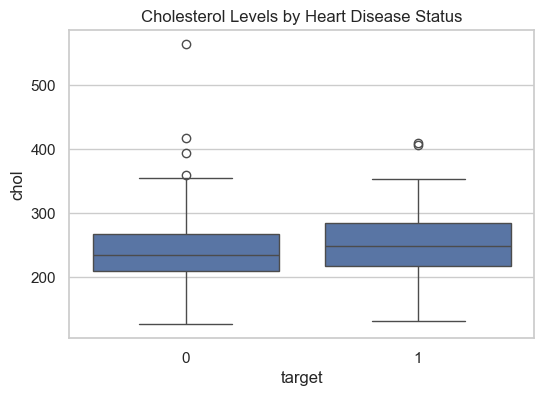

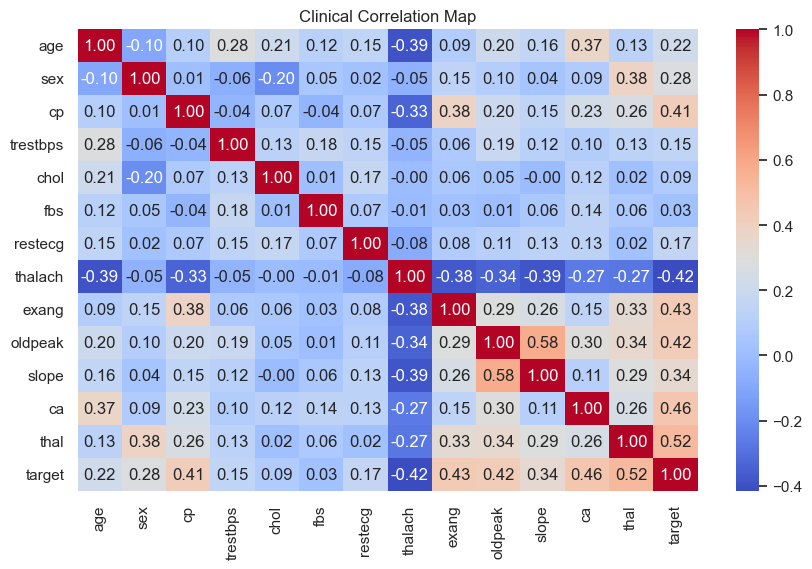

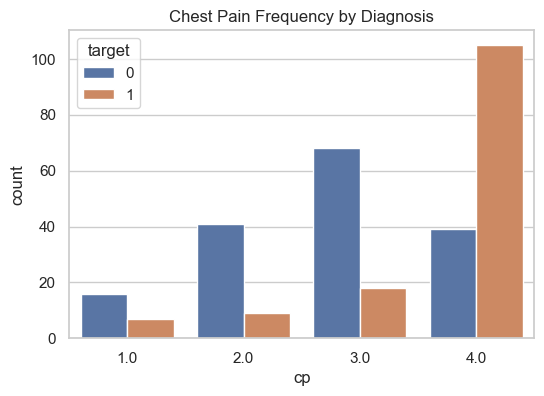

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns


def generate_visuals(data: pd.DataFrame) -> None:
    """Generates the 3 required visualizations for the project."""
    sns.set_theme(style="whitegrid")

    plt.figure(figsize=(6, 4))
    sns.boxplot(x="target", y="chol", data=data)
    plt.title("Cholesterol Levels by Heart Disease Status")
    plt.show()

    plt.figure(figsize=(10, 6))
    sns.heatmap(data.corr(), annot=True, cmap="coolwarm", fmt=".2f")
    plt.title("Clinical Correlation Map")
    plt.show()

    plt.figure(figsize=(6, 4))
    sns.countplot(x="cp", hue="target", data=data)
    plt.title("Chest Pain Frequency by Diagnosis")
    plt.show()


generate_visuals(df)


In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
import pandas as pd

def train_models(
    X_tr: pd.DataFrame, y_tr: pd.Series, X_te: pd.DataFrame, y_te: pd.Series
) -> dict:

    results = {}

    log_reg = LogisticRegression(max_iter=2000, solver="liblinear")
    log_params = {"C": [0.1, 1, 10]}  # Simplified grid search
    grid_log = GridSearchCV(log_reg, log_params, cv=3)
    grid_log.fit(X_tr, y_tr)
    results["Logistic Regression"] = grid_log.best_estimator_

    svm_model = SVC(kernel="rbf", random_state=42)
    svm_params = {"C": [0.1, 1, 10], "gamma": ["scale", "auto"]}
    grid_svm = GridSearchCV(svm_model, svm_params, cv=3)
    grid_svm.fit(X_tr, y_tr)
    results["SVM"] = grid_svm.best_estimator_

    print(f"LogReg Train Acc: {grid_log.best_score_:.2f}")
    print(f"LogReg Test Acc: {grid_log.score(X_te, y_te):.2f}")
    print(f"SVM Train Acc: {grid_svm.best_score_:.2f}")
    print(f"SVM Test Acc: {grid_svm.score(X_te, y_te):.2f}")

    return results


trained_models = train_models(X_train, y_train, X_test, y_test)



LogReg Train Acc: 0.83
LogReg Test Acc: 0.87
SVM Train Acc: 0.68
SVM Test Acc: 0.74


In [9]:
best_model = trained_models["Logistic Regression"]

coefficients = pd.DataFrame(
    {"Feature": X.columns, "Coefficient": best_model.coef_[0]}
).sort_values(by="Coefficient", ascending=False)

print(coefficients)


     Feature  Coefficient
11        ca     1.210750
1        sex     0.956117
8      exang     0.683735
2         cp     0.391024
12      thal     0.381020
10     slope     0.293535
6    restecg     0.248125
9    oldpeak     0.146524
3   trestbps     0.011024
4       chol     0.002422
7    thalach    -0.031572
0        age    -0.039573
5        fbs    -0.317469
